# 08 Calibration And Report Export

I leave report export until the end because these artefacts should only package quantities that have already been defined and checked. This notebook writes the lab-facing summaries, calibration templates, holograms, and report figures.

In [1]:
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from vbb_study import setup_study, vbb_style

PATHS = setup_study.bootstrap(Path.cwd())
ROOT = PATHS["root"]
PUB_ROOT = PATHS["publication"]
LAB_ROOT = PATHS["modular_lab"]

import bessel_twin_core as bt
from Publication_Study import publication_diagnostics as pdiag

## Editable Notebook Controls

<!-- STAGE88: editable controls -->

This cell exposes the intended user-editable controls for exploratory runs. The locked stage logic below is preserved: changing these controls is for local investigation unless the notebook explicitly wires a value into a regenerated canonical output. Keep QA, caveats, and fail/marginal labels visible. For fast beam-to-sample exploration use the quicklook notebook; for publication-grade outputs use the locked stage runner.


In [ ]:
# STAGE88: visible editable controls for exploratory notebook use.
from vbb_study.publication import notebook_controls as nb_controls

NOTEBOOK_CONTROLS = nb_controls.make_notebook_controls(stage='publication_exports')
try:
    display(nb_controls.describe_controls(NOTEBOOK_CONTROLS))
except NameError:
    print(nb_controls.describe_controls(NOTEBOOK_CONTROLS).to_string(index=False))


In [ ]:
# PHASE7-PUBEXP: schema and source documentation
# This notebook is the PAPER-FACING export layer.
# It regenerates outputs from the scalar engine.
# Paper-facing CSVs are written to:
#   outputs/csv/publication_exports/
# They are DISTINCT from the study-wide CSVs in:
#   outputs/csv/publication_study/
#
# Canonical schema version (source_schema_version in every CSV):
from vbb_study.publication.tables import (
    SCALAR_OUTPUT_SCHEMA_VERSION,
    annotate_scalar_row,
    propagation_power_label as _power_label,
)
import os as _os
_run_id = _os.environ.get("STRUCTURED_BEAM_RUN_ID", "")
print(f"Schema version:  {SCALAR_OUTPUT_SCHEMA_VERSION}")
print(f"Run ID:          {_run_id or '(interactive)'}")
print()
print("Source study CSVs (study-generated inputs, if using pre-computed results):")
print("  outputs/csv/publication_study/scalar_shortlist_realistic_summary.csv")
print("  outputs/csv/publication_study/scalar_shortlist_ideal_vs_lab_comparison.csv")
print()
print("Paper-facing output location: outputs/csv/publication_exports/")


In [2]:
PRESET = "fast"
PATH = "realistic"
PUB_OUT = pdiag.publication_output_tree(PATHS["outputs"])
base = bt.default_config(PRESET)

In [ ]:
# PHASE7-PUBEXP: create publication_exports output directory
# Write paper-facing CSVs here, not into publication_study/ (the study layer).
PUB_EXP_CSV = PATHS["csv"] / "publication_exports"
PUB_EXP_CSV.mkdir(parents=True, exist_ok=True)
print(f"Publication export CSV dir: {PUB_EXP_CSV}")


## Realistic Shortlist Summary

Use the shared publication shortlist so every report export stays aligned with the main case-diagnostics notebook.

In [3]:
bundles = pdiag.build_shortlist_bundles(pdiag.DEFAULT_SHORTLIST, base, preset=PRESET, path=PATH)
summary = pdiag.shortlist_summary_dataframe(bundles)
summary.to_csv(PUB_EXP_CSV / "scalar_shortlist_realistic_summary.csv", index=False)
display(summary)

,case_id,path,ell,target_core_diameter_um,target_bessel_length_um,gamma_slm_deg,magnification_to_sample,ring_radius_um,core_radius_um,feature_diameter_um,...,bessel_region_um,bessel_region_start_um,bessel_region_end_um,line_proxy_threshold_length_um,qa_status,phase_sampling_label,focal_sampling_label,axial_sampling_label,focal_kt_nyquist_over_kr,input_energy_uJ
0,ell0_core3_L150,realistic,0,3.0,150.0,0.242851,0.008071,0.000000,0.731480,1.462960,...,38.25,369.75,408.00,0.0,marginal,pass,pass,pass,7.799569,10.0
1,ell3_core3_L150,realistic,3,3.0,150.0,0.242851,0.008071,2.156831,1.491932,4.313661,...,25.50,382.50,408.00,0.0,marginal,pass,pass,pass,7.799569,10.0
2,ell5_core4_L200,realistic,5,4.0,200.0,0.182139,0.008071,3.422952,2.630917,6.845904,...,25.50,395.25,420.75,0.0,marginal,pass,pass,pass,10.399426,20.0


## Calibration Template

Generate a lab-facing table that pairs simulated predictions with blank microscope-measurement columns.

In [4]:
calibration = summary[["case_id", "ell", "input_energy_uJ", "target_core_diameter_um", "target_bessel_length_um", "gamma_slm_deg", "pulse_energy_at_sample_uJ", "peak_fluence_J_cm2", "incubated_threshold_J_cm2", "bessel_zone_um"]].copy()
calibration = calibration.rename(columns={
    "pulse_energy_at_sample_uJ": "predicted_sample_energy_uJ",
    "peak_fluence_J_cm2": "predicted_peak_fluence_J_cm2",
    "incubated_threshold_J_cm2": "predicted_threshold_J_cm2",
    "bessel_zone_um": "predicted_bessel_zone_um",
})
calibration["measured_ring_radius_um"] = pd.NA
calibration["measured_track_length_um"] = pd.NA
calibration["measured_track_width_um"] = pd.NA
calibration["measured_side_lobe_note"] = ""
calibration["microscope_image_path"] = ""
calibration.to_csv(PUB_EXP_CSV / "scalar_calibration_template.csv", index=False)
display(calibration)

,case_id,ell,input_energy_uJ,target_core_diameter_um,target_bessel_length_um,gamma_slm_deg,predicted_sample_energy_uJ,predicted_peak_fluence_J_cm2,predicted_threshold_J_cm2,predicted_bessel_zone_um,measured_ring_radius_um,measured_track_length_um,measured_track_width_um,measured_side_lobe_note,microscope_image_path
0,ell0_core3_L150,0,10.0,3.0,150.0,0.242851,2.6244,31.075855,0.802954,93.125000,<NA>,<NA>,<NA>,,
1,ell3_core3_L150,3,10.0,3.0,150.0,0.242851,2.6244,7.117555,0.802954,78.341602,<NA>,<NA>,<NA>,,
2,ell5_core4_L200,5,20.0,4.0,200.0,0.182139,5.2488,11.147966,0.802954,75.598414,<NA>,<NA>,<NA>,,


## Export Per-Case Artifacts

For each shortlist case, export the hologram files, diagnostics figures, energy-budget table, and a manifest row linking the outputs together.

In [5]:
rows = []
for bundle in bundles:
    spec = bundle["spec"]
    cfg = pdiag.config_from_shortlist_item(base, spec)
    design = bt.compute_design_from_targets(cfg.laser, cfg.target, cfg.material)
    hologram_paths = bt.export_hologram_png(cfg, PUB_OUT["holograms"], basename=spec["label"], design=design)
    report_paths = pdiag.export_case_report_artifacts(bundle, PUB_OUT["figures"], PUB_OUT["csv"])
    rows.append({
        "case_id": bundle["case_id"],
        "png": str(hologram_paths["png"]),
        "json": str(hologram_paths["json"]),
        "diagnostics_png": str(report_paths["diagnostics_png"]),
        "plane_montage_png": str(report_paths["plane_montage_png"]),
        "summary_csv": str(report_paths["summary_csv"]),
        "energy_budget_csv": str(report_paths["energy_budget_csv"]),
        "predicted_zone_um": bundle["result"]["metrics"]["bessel_zone_um"],
        "predicted_peak_fluence_J_cm2": bundle["result"]["metrics"]["peak_fluence_J_cm2"],
    })
manifest = pd.DataFrame(rows)
manifest.to_csv(PUB_EXP_CSV / "scalar_shortlist_artifact_manifest.csv", index=False)
display(manifest)

,case_id,png,json,diagnostics_png,plane_montage_png,summary_csv,energy_budget_csv,predicted_zone_um,predicted_peak_fluence_J_cm2
0,ell0_core3_L150,C:\PhD\Code\Publication_Study\outputs\hologram...,C:\PhD\Code\Publication_Study\outputs\hologram...,C:\PhD\Code\Publication_Study\outputs\figures\...,C:\PhD\Code\Publication_Study\outputs\figures\...,C:\PhD\Code\Publication_Study\outputs\csv\publ...,C:\PhD\Code\Publication_Study\outputs\csv\publ...,93.125000,31.075855
1,ell3_core3_L150,C:\PhD\Code\Publication_Study\outputs\hologram...,C:\PhD\Code\Publication_Study\outputs\hologram...,C:\PhD\Code\Publication_Study\outputs\figures\...,C:\PhD\Code\Publication_Study\outputs\figures\...,C:\PhD\Code\Publication_Study\outputs\csv\publ...,C:\PhD\Code\Publication_Study\outputs\csv\publ...,78.341602,7.117555
2,ell5_core4_L200,C:\PhD\Code\Publication_Study\outputs\hologram...,C:\PhD\Code\Publication_Study\outputs\hologram...,C:\PhD\Code\Publication_Study\outputs\figures\...,C:\PhD\Code\Publication_Study\outputs\figures\...,C:\PhD\Code\Publication_Study\outputs\csv\publ...,C:\PhD\Code\Publication_Study\outputs\csv\publ...,75.598414,11.147966


## Lab-Facing Comparison Figures

Use compact figures to compare energy delivery and predicted optical signatures across the shortlist.

,case_id,ell,input_energy_uJ,target_core_diameter_um,target_bessel_length_um,gamma_slm_deg,pulse_energy_at_sample_uJ,bessel_zone_um,peak_fluence_J_cm2,side_to_core_peak_ratio,fluence_to_threshold_ratio
0,ell0_core3_L150,0,10.0,3.0,150.0,0.242851,2.6244,93.125000,31.075855,2.289491,38.701918
1,ell3_core3_L150,3,10.0,3.0,150.0,0.242851,2.6244,78.341602,7.117555,0.867118,8.864214
2,ell5_core4_L200,5,20.0,4.0,200.0,0.182139,5.2488,75.598414,11.147966,0.356839,13.883695


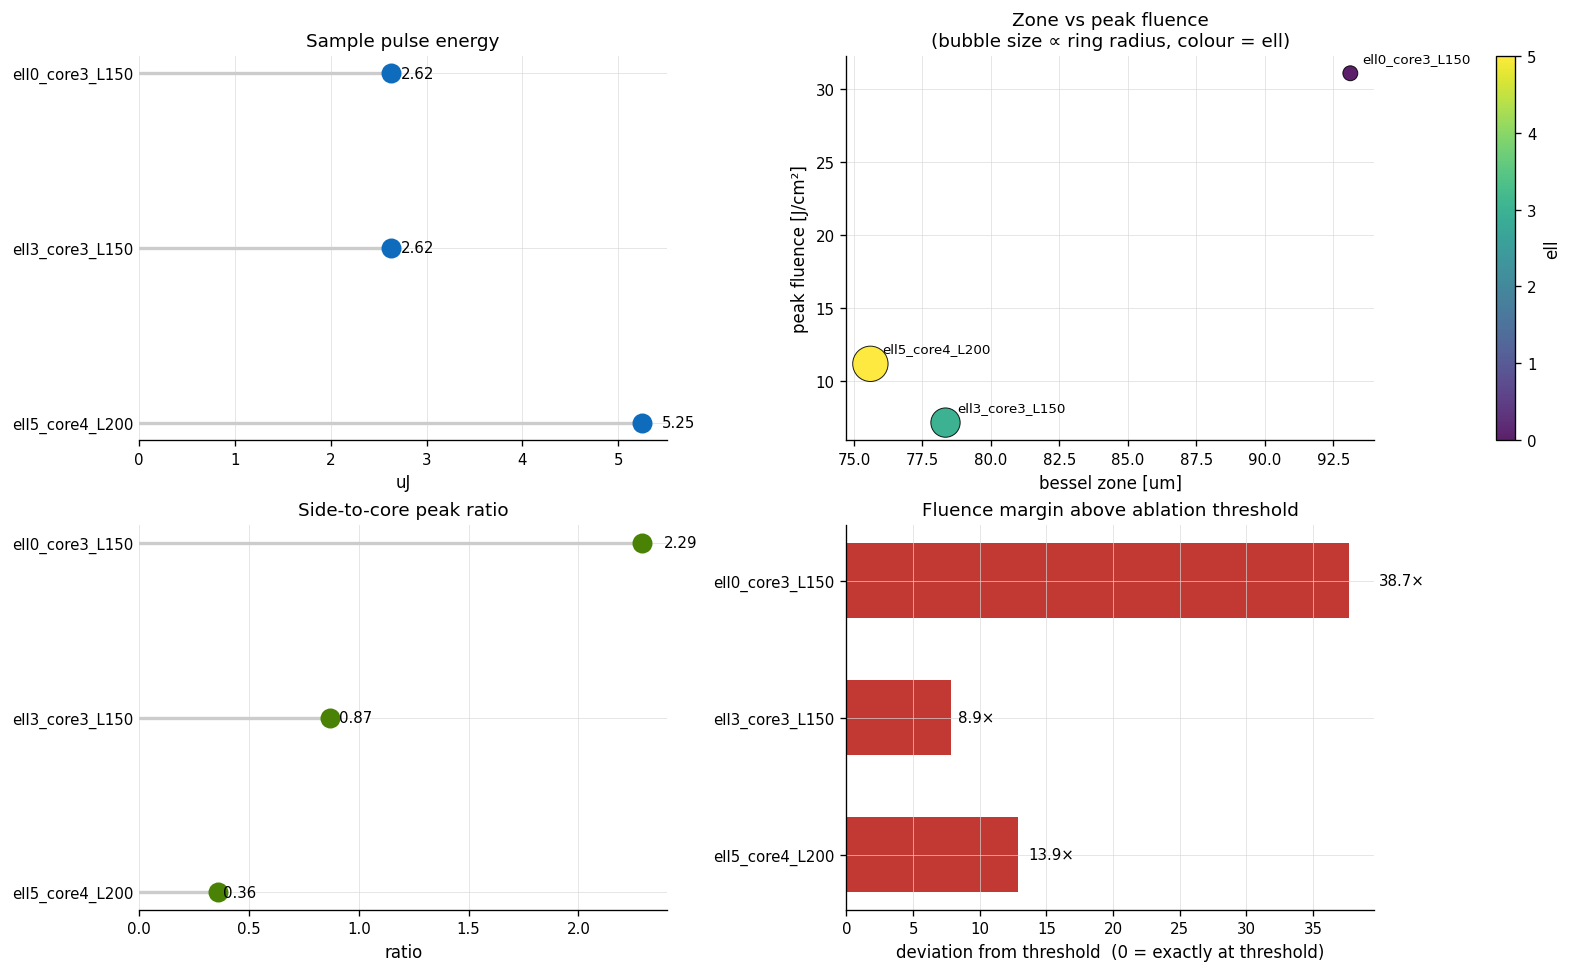

C:\PhD\Code\Publication_Study\outputs\figures\publication_study\shortlist_lab_comparison.png


In [6]:
import numpy as np

comparison = summary.copy()
threshold = comparison["incubated_threshold_J_cm2"].replace(0, pd.NA)
comparison["fluence_to_threshold_ratio"] = comparison["peak_fluence_J_cm2"] / threshold
comparison_table = comparison[[
    "case_id", "ell", "input_energy_uJ", "target_core_diameter_um", "target_bessel_length_um",
    "gamma_slm_deg", "pulse_energy_at_sample_uJ", "bessel_zone_um",
    "peak_fluence_J_cm2", "side_to_core_peak_ratio", "fluence_to_threshold_ratio",
]].sort_values(["ell", "target_bessel_length_um"])
comparison_table.to_csv(PUB_EXP_CSV / "scalar_shortlist_ideal_vs_lab_comparison.csv", index=False)
display(comparison_table)

cases = comparison["case_id"].tolist()
n = len(cases)

fig, ax = plt.subplots(2, 2, figsize=(13, 8.0), constrained_layout=True)

# --- top-left: lollipop for sample pulse energy ---
vals = comparison["pulse_energy_at_sample_uJ"].tolist()
for i, (lbl, v) in enumerate(zip(cases, vals)):
    ax[0, 0].plot([0, v], [i, i], color="#cccccc", lw=2.0, solid_capstyle="round")
    ax[0, 0].plot(v, i, "o", color="#0f6cbd", ms=11, zorder=3)
    ax[0, 0].text(v * 1.04, i, f"{v:.2f}", va="center", fontsize=9)
ax[0, 0].set_yticks(range(n), cases)
ax[0, 0].invert_yaxis()
ax[0, 0].set_xlabel("uJ")
ax[0, 0].set_title("Sample pulse energy")
ax[0, 0].set_xlim(left=0)
ax[0, 0].spines[["top", "right", "left"]].set_visible(False)
ax[0, 0].tick_params(axis="y", length=0)

# --- top-right: bubble scatter — zone vs fluence, bubble size ∝ ring radius ---
ring_r = comparison["ring_radius_um"].clip(lower=0.1)
sizes = np.interp(ring_r, [ring_r.min(), ring_r.max()], [80, 450])
scatter = ax[0, 1].scatter(
    comparison["bessel_zone_um"], comparison["peak_fluence_J_cm2"],
    s=sizes, c=comparison["ell"], cmap="viridis",
    edgecolors="black", linewidths=0.6, zorder=3, alpha=0.88,
)
for _, row in comparison.iterrows():
    ax[0, 1].annotate(row["case_id"], (row["bessel_zone_um"], row["peak_fluence_J_cm2"]),
                      textcoords="offset points", xytext=(7, 7), fontsize=8)
ax[0, 1].set_title("Zone vs peak fluence\n(bubble size ∝ ring radius, colour = ell)")
ax[0, 1].set_xlabel("bessel zone [um]")
ax[0, 1].set_ylabel("peak fluence [J/cm\u00b2]")
fig.colorbar(scatter, ax=ax[0, 1], label="ell")
ax[0, 1].spines[["top", "right"]].set_visible(False)

# --- bottom-left: lollipop for side-to-core peak ratio ---
vals = comparison["side_to_core_peak_ratio"].tolist()
for i, (lbl, v) in enumerate(zip(cases, vals)):
    ax[1, 0].plot([0, v], [i, i], color="#cccccc", lw=2.0, solid_capstyle="round")
    ax[1, 0].plot(v, i, "o", color="#498205", ms=11, zorder=3)
    ax[1, 0].text(v * 1.04 + 0.01, i, f"{v:.2f}", va="center", fontsize=9)
ax[1, 0].set_yticks(range(n), cases)
ax[1, 0].invert_yaxis()
ax[1, 0].set_xlabel("ratio")
ax[1, 0].set_title("Side-to-core peak ratio")
ax[1, 0].set_xlim(left=0)
ax[1, 0].spines[["top", "right", "left"]].set_visible(False)
ax[1, 0].tick_params(axis="y", length=0)

# --- bottom-right: diverging bar — deviation from ablation threshold ---
devs = (comparison["fluence_to_threshold_ratio"].fillna(1.0) - 1.0).tolist()
colors_div = ["#c23934" if d >= 0 else "#0f6cbd" for d in devs]
bars = ax[1, 1].barh(cases, devs, color=colors_div, height=0.55)
ax[1, 1].axvline(0, color="black", lw=1.2)
ax[1, 1].set_xlabel("deviation from threshold  (0 = exactly at threshold)")
ax[1, 1].set_title("Fluence margin above ablation threshold")
for bar, d in zip(bars, devs):
    sign = 1 if d >= 0 else -1
    ax[1, 1].text(d + sign * max(abs(d) * 0.06, 0.5), bar.get_y() + bar.get_height() / 2,
                  f"{d + 1:.1f}\u00d7", va="center", ha="left" if d >= 0 else "right", fontsize=9)
ax[1, 1].spines[["top", "right"]].set_visible(False)
ax[1, 1].invert_yaxis()

comparison_path = PUB_OUT["figures"] / "shortlist_lab_comparison.png"
fig.savefig(comparison_path, dpi=220, bbox_inches="tight")
plt.show()
print(comparison_path)

## Vortex-Bessel Charge Sweep

Hold the target geometry and input energy fixed while varying topological charge so the report shows how vortex order changes ring structure, axial extent, and energy confinement.

,case_id,ell,gamma_slm_deg,ring_radius_um,ring_width_um,bessel_zone_um,peak_fluence_J_cm2,side_to_core_peak_ratio,pulse_energy_at_sample_uJ
0,ell0_core3_L150_E10,0,0.242851,0.000000,1.462960,93.125000,31.075855,2.289491,2.6244
1,ell1_core3_L150_E10,1,0.242851,0.888103,1.342616,87.200452,11.304177,1.021772,2.6244
2,ell3_core3_L150_E10,3,0.242851,2.156831,1.361438,78.341602,7.117555,0.867118,2.6244
3,ell5_core3_L150_E10,5,0.242851,3.425325,1.534396,67.416145,5.830561,0.340773,2.6244
4,ell7_core3_L150_E10,7,0.242851,4.439371,1.652222,65.647242,4.741592,0.343028,2.6244


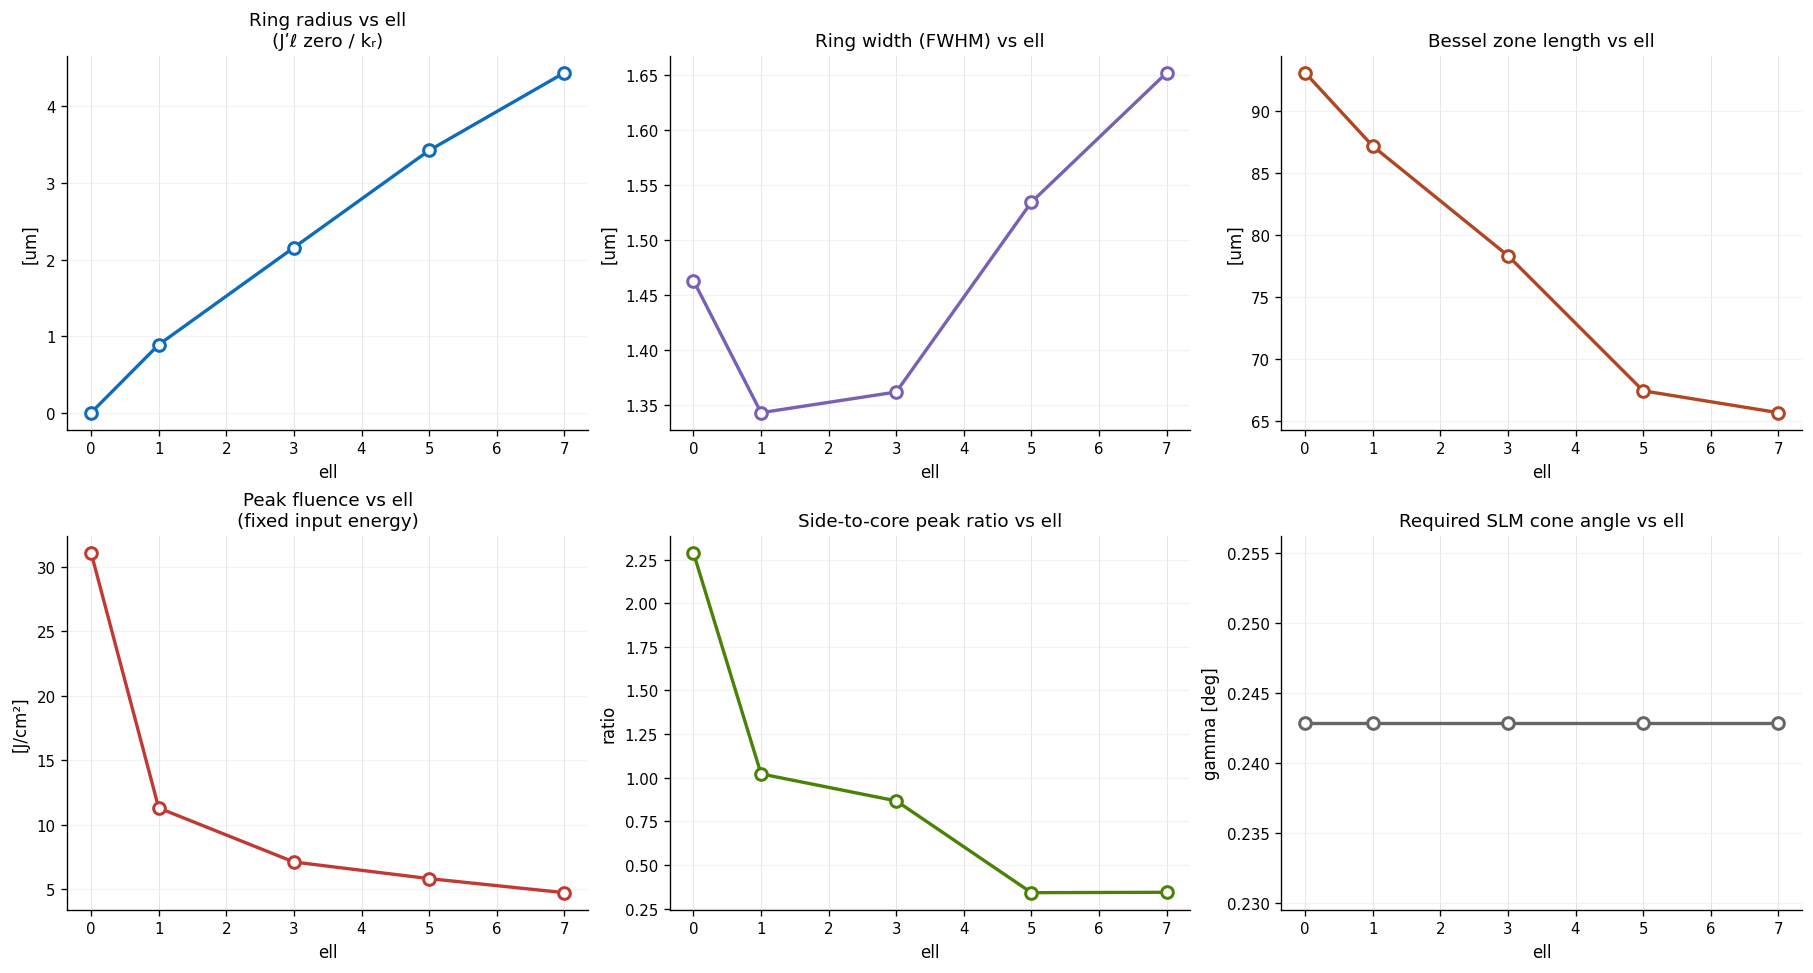

C:\PhD\Code\Publication_Study\outputs\figures\publication_study\vortex_charge_sweep.png


In [7]:
charge_sweep_specs = [
    {"label": f"ell{ell}_core3_L150_E10", "ell": ell, "D_um": 3.0, "L_um": 150.0, "Ein_uJ": 10.0}
    for ell in (0, 1, 3, 5, 7)
]
charge_bundles = pdiag.build_shortlist_bundles(charge_sweep_specs, base, preset=PRESET, path=PATH)
charge_rows = []
for bundle in charge_bundles:
    metrics = bundle["result"]["metrics"]
    charge_rows.append({
        "case_id": bundle["case_id"],
        "ell": metrics["ell"],
        "gamma_slm_deg": metrics["gamma_slm_deg"],
        "ring_radius_um": metrics["ring_radius_um"],
        "ring_width_um": metrics["ring_width_um"],
        "bessel_zone_um": metrics["bessel_zone_um"],
        "peak_fluence_J_cm2": metrics["peak_fluence_J_cm2"],
        "side_to_core_peak_ratio": metrics["side_to_core_peak_ratio"],
        "pulse_energy_at_sample_uJ": metrics["pulse_energy_at_sample_uJ"],
    })
charge_df = pd.DataFrame(charge_rows).sort_values("ell").reset_index(drop=True)
charge_df.to_csv(PUB_EXP_CSV / "scalar_vortex_charge_sweep.csv", index=False)
display(charge_df)

import numpy as np
ells = charge_df["ell"].tolist()
mk = dict(marker="o", linewidth=2.0, markersize=7, markerfacecolor="white", markeredgewidth=1.8)

fig, ax = plt.subplots(2, 3, figsize=(15, 8.0), constrained_layout=True)

ax[0, 0].plot(ells, charge_df["ring_radius_um"], color="#0f6cbd", **mk)
ax[0, 0].set_title("Ring radius vs ell\n(J\u02b9\u2113 zero / k\u1d63)")
ax[0, 0].set_xlabel("ell"); ax[0, 0].set_ylabel("[um]")

ax[0, 1].plot(ells, charge_df["ring_width_um"], color="#7960b5", **mk)
ax[0, 1].set_title("Ring width (FWHM) vs ell")
ax[0, 1].set_xlabel("ell"); ax[0, 1].set_ylabel("[um]")

ax[0, 2].plot(ells, charge_df["bessel_zone_um"], color="#b14623", **mk)
ax[0, 2].set_title("Bessel zone length vs ell")
ax[0, 2].set_xlabel("ell"); ax[0, 2].set_ylabel("[um]")

ax[1, 0].plot(ells, charge_df["peak_fluence_J_cm2"], color="#c23934", **mk)
ax[1, 0].set_title("Peak fluence vs ell\n(fixed input energy)")
ax[1, 0].set_xlabel("ell"); ax[1, 0].set_ylabel("[J/cm\u00b2]")

ax[1, 1].plot(ells, charge_df["side_to_core_peak_ratio"], color="#498205", **mk)
ax[1, 1].set_title("Side-to-core peak ratio vs ell")
ax[1, 1].set_xlabel("ell"); ax[1, 1].set_ylabel("ratio")

ax[1, 2].plot(ells, charge_df["gamma_slm_deg"], color="#666666", **mk)
ax[1, 2].set_title("Required SLM cone angle vs ell")
ax[1, 2].set_xlabel("ell"); ax[1, 2].set_ylabel("gamma [deg]")

for a in ax.ravel():
    a.spines[["top", "right"]].set_visible(False)
    a.grid(axis="y", color="#eeeeee", lw=0.8)

charge_fig_path = PUB_OUT["figures"] / "vortex_charge_sweep.png"
fig.savefig(charge_fig_path, dpi=220, bbox_inches="tight")
plt.show()
print(charge_fig_path)

## Charge-Length Sensitivity Grid

Reintroduce a compact variable sweep by scanning vortex charge and requested Bessel length at fixed core diameter and input energy. This keeps the report tied to the broader study while staying focused on vortex-Bessel behavior.

,ell,target_bessel_length_um,gamma_slm_deg,bessel_zone_um,peak_fluence_J_cm2,side_to_core_peak_ratio
0,0,100.0,0.161901,80.154103,36.034363,1.337714
1,0,150.0,0.242851,93.125000,31.075855,2.289491
2,0,200.0,0.323800,205.924733,6.435025,1.042135
3,0,250.0,0.404748,275.459058,3.449112,0.286540
4,1,100.0,0.161901,73.158597,13.254675,1.003511
5,1,150.0,0.242851,87.200452,11.304177,1.021772
6,1,200.0,0.323800,63.041090,2.877448,1.000000
7,1,250.0,0.404748,194.313947,2.093577,1.000000
8,3,100.0,0.161901,77.640316,7.145381,0.860436
9,3,150.0,0.242851,78.341602,7.117555,0.867118


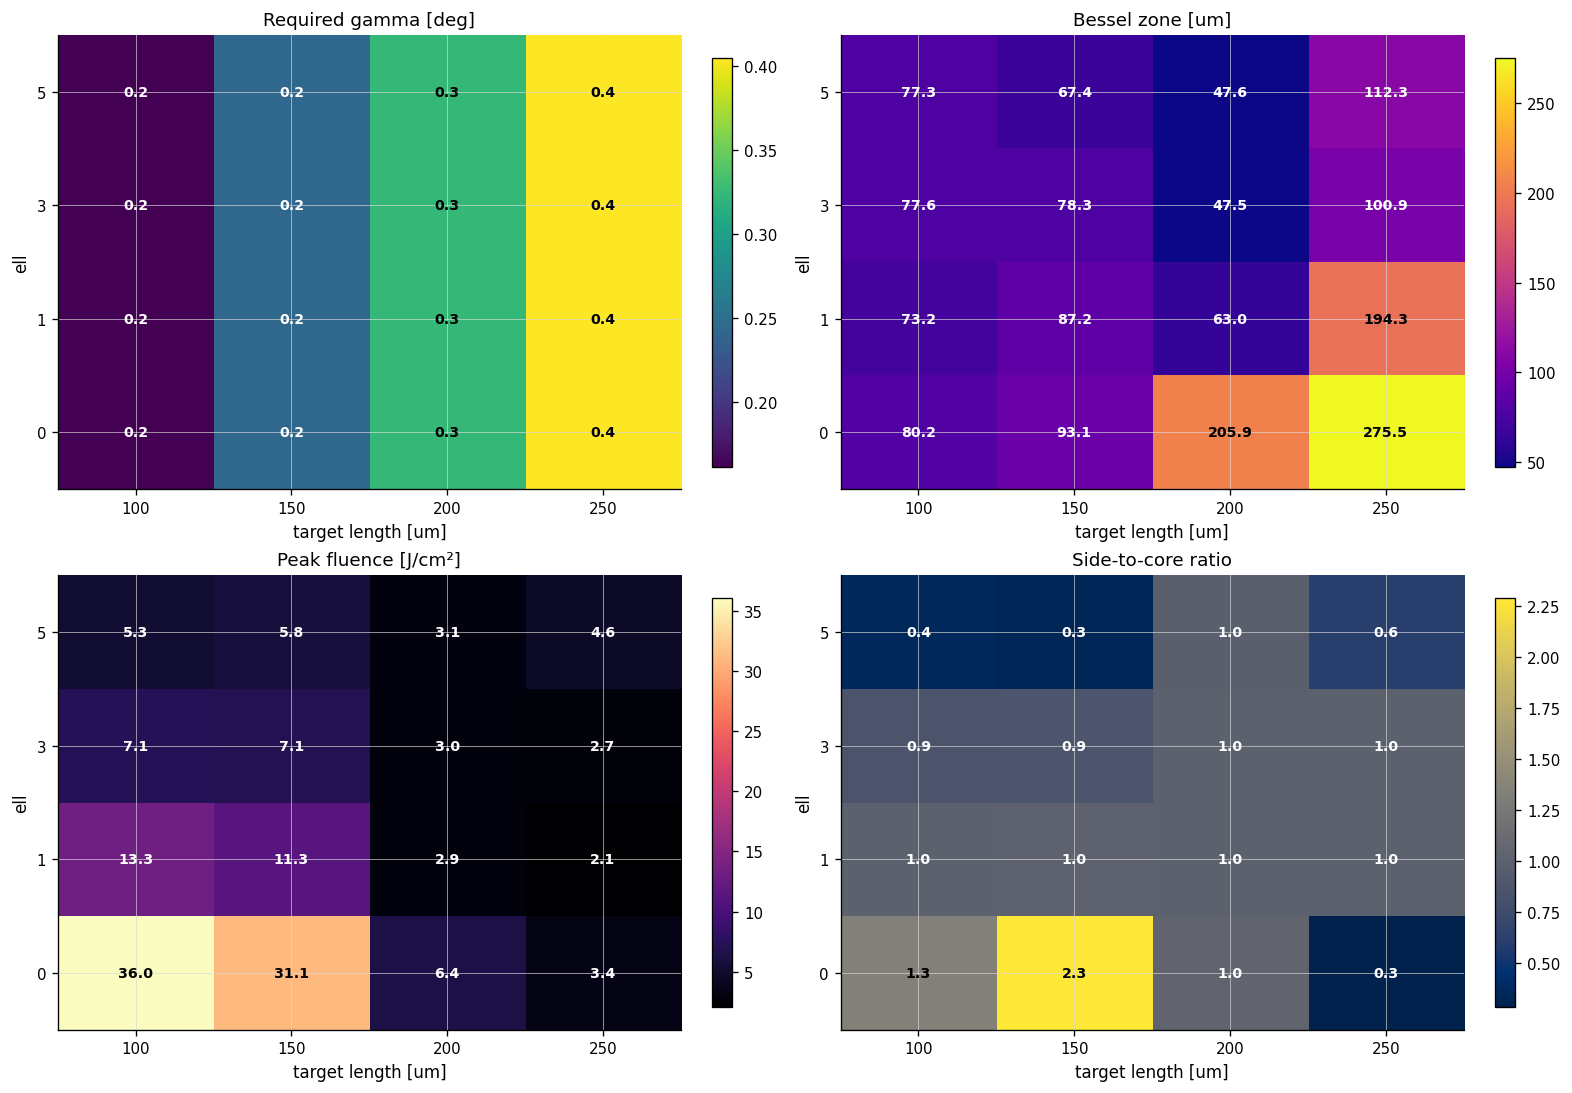

C:\PhD\Code\Publication_Study\outputs\figures\publication_study\vortex_charge_length_sensitivity.png


In [8]:
import numpy as np

charge_length_specs = [
    {
        "label": f"ell{ell}_L{int(length_um)}_core3_E10",
        "ell": ell,
        "D_um": 3.0,
        "L_um": float(length_um),
        "Ein_uJ": 10.0,
    }
    for ell in (0, 1, 3, 5)
    for length_um in (100.0, 150.0, 200.0, 250.0)
]
charge_length_bundles = pdiag.build_shortlist_bundles(charge_length_specs, base, preset=PRESET, path=PATH)
charge_length_df = (
    pdiag.shortlist_summary_dataframe(charge_length_bundles)
    .sort_values(["ell", "target_bessel_length_um"])
    .reset_index(drop=True)
)
charge_length_df.to_csv(PUB_EXP_CSV / "scalar_vortex_charge_length_sensitivity.csv", index=False)
display(
    charge_length_df[[
        "ell", "target_bessel_length_um", "gamma_slm_deg",
        "bessel_zone_um", "peak_fluence_J_cm2", "side_to_core_peak_ratio",
    ]]
)

heatmap_specs = [
    ("gamma_slm_deg",       "Required gamma [deg]",     "viridis"),
    ("bessel_zone_um",      "Bessel zone [um]",          "plasma"),
    ("peak_fluence_J_cm2",  "Peak fluence [J/cm\u00b2]", "magma"),
    ("side_to_core_peak_ratio", "Side-to-core ratio",    "cividis"),
]
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
for axis, (column, title, cmap) in zip(axes.ravel(), heatmap_specs):
    pivot = (
        charge_length_df.pivot(index="ell", columns="target_bessel_length_um", values=column)
        .sort_index()
        .sort_index(axis=1)
    )
    data = pivot.to_numpy(dtype=float)
    image = axis.imshow(data, origin="lower", aspect="auto", cmap=cmap)
    axis.set_xticks(range(len(pivot.columns)), [f"{int(v)}" for v in pivot.columns])
    axis.set_yticks(range(len(pivot.index)), [str(v) for v in pivot.index])
    axis.set_xlabel("target length [um]")
    axis.set_ylabel("ell")
    axis.set_title(title)
    fig.colorbar(image, ax=axis, shrink=0.9)
    # Annotate each cell with its numeric value; pick text colour by background luminance
    cmap_fn = plt.colormaps[cmap]
    vmin, vmax = float(np.nanmin(data)), float(np.nanmax(data))
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = float(data[i, j])
            norm_val = (val - vmin) / (vmax - vmin + 1e-30)
            rgba = cmap_fn(norm_val)
            lum = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
            txt_color = "white" if lum < 0.5 else "black"
            axis.text(j, i, f"{val:.1f}", ha="center", va="center",
                      fontsize=8.5, color=txt_color, fontweight="bold")

charge_length_fig_path = PUB_OUT["figures"] / "vortex_charge_length_sensitivity.png"
fig.savefig(charge_length_fig_path, dpi=220, bbox_inches="tight")
plt.show()
print(charge_length_fig_path)

## Radial Profile Overlay

Overlay the normalised transverse radial intensity profiles for every charge value in the sweep. The ring peak shifts outward with ell (set by the first zero of J'_ℓ), the dark core widens, and the FWHM ring width broadens — all three effects are immediately visible in one plot.

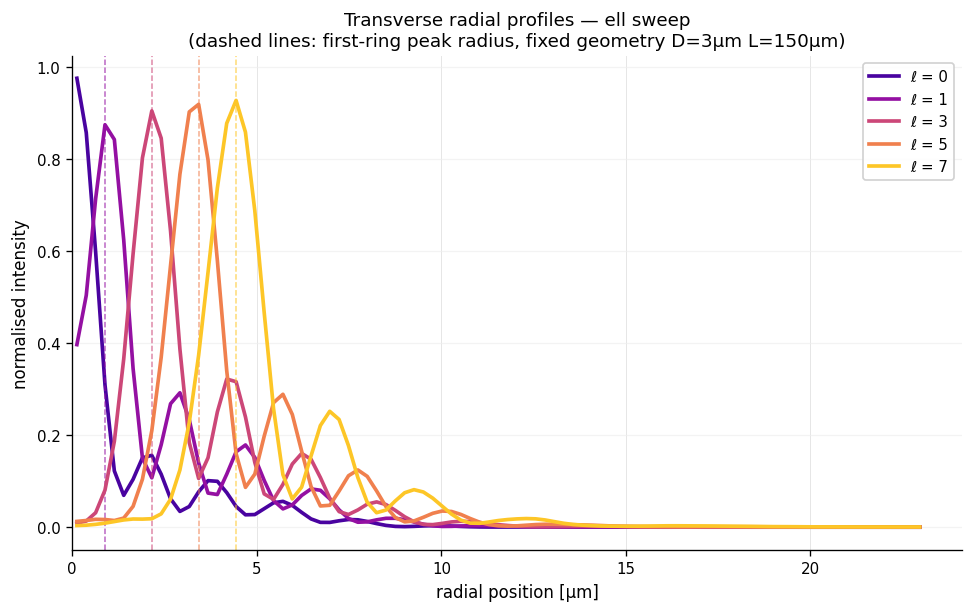

C:\PhD\Code\Publication_Study\outputs\figures\publication_study\radial_profile_overlay.png


In [9]:
import numpy as np

palette = plt.cm.plasma(np.linspace(0.12, 0.88, len(charge_bundles)))

fig, ax = plt.subplots(1, 1, figsize=(8, 5), constrained_layout=True)
for bundle, color in zip(charge_bundles, palette):
    metrics = bundle["result"]["metrics"]
    ell_val = metrics["ell"]
    r_um = np.asarray(bundle["radial"]["r_profile_m"]) / bt.um
    profile = np.asarray(bundle["radial"]["radial_profile_smooth"])
    ring_r = float(metrics["ring_radius_um"])
    ax.plot(r_um, profile, color=color, linewidth=2.2, label=f"\u2113 = {ell_val}")
    if ring_r > 0:
        ax.axvline(ring_r, color=color, lw=0.9, linestyle="--", alpha=0.65)

ax.set_xlabel("radial position [\u03bcm]")
ax.set_ylabel("normalised intensity")
ax.set_title("Transverse radial profiles — ell sweep\n"
             "(dashed lines: first-ring peak radius, fixed geometry D=3\u03bcm L=150\u03bcm)")
ax.legend(loc="upper right", framealpha=0.9)
ax.set_xlim(left=0)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#eeeeee", lw=0.8)

radial_path = PUB_OUT["figures"] / "radial_profile_overlay.png"
fig.savefig(radial_path, dpi=220, bbox_inches="tight")
plt.show()
print(radial_path)

## x-z Cross-Sections and Axial Peak-Intensity Traces

Each column shows one topological charge. **Top row**: the x-z intensity cross-section (hot colormap, normalised per case), with cyan dashed lines at the Bessel zone boundaries. **Bottom row**: normalised peak-in-plane intensity along z; the shaded band shows the FWHM Bessel zone. For vortex beams the on-axis intensity is zero so the peak-in-plane trace is used instead.

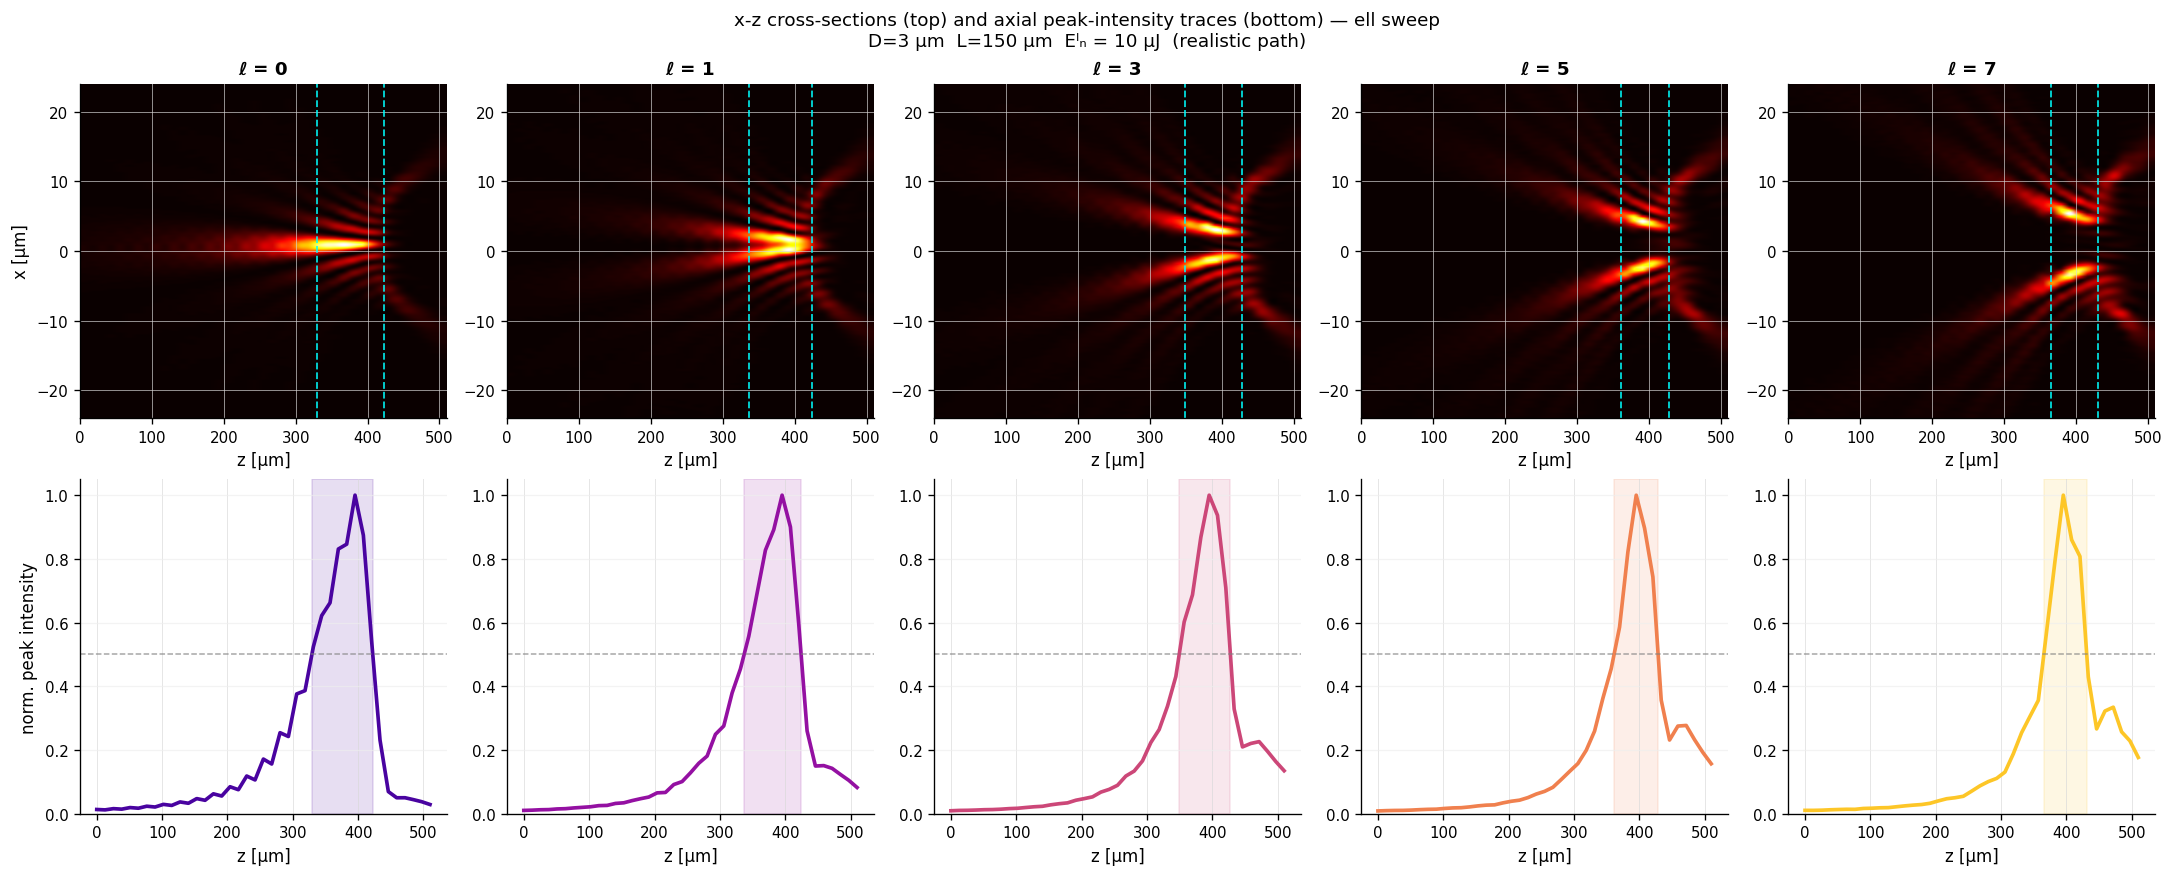

C:\PhD\Code\Publication_Study\outputs\figures\publication_study\axial_xz_traces.png


In [10]:
import numpy as np

n_cases = len(charge_bundles)
palette = plt.cm.plasma(np.linspace(0.12, 0.88, n_cases))

fig, axes = plt.subplots(2, n_cases, figsize=(3.6 * n_cases, 7.2), constrained_layout=True)

for col, (bundle, color) in enumerate(zip(charge_bundles, palette)):
    metrics = bundle["result"]["metrics"]
    ell_val = metrics["ell"]
    volume = bundle["result"]["volume"]
    z_um = np.asarray(volume["z"]) / bt.um
    crop_x = np.asarray(volume["crop_grid"]["x"]) / bt.um
    xz = np.asarray(volume["xz"], dtype=float)
    peak = np.asarray(volume["peak"], dtype=float)
    xz_n = xz / (float(np.max(xz)) + 1e-30)
    peak_n = peak / (float(np.max(peak)) + 1e-30)
    z0 = float(metrics.get("zone_start_um", float("nan")))
    z1 = float(metrics.get("zone_end_um", float("nan")))

    # top: x-z cross-section
    ax_xz = axes[0, col]
    ax_xz.imshow(
        xz_n, origin="lower", aspect="auto", cmap="hot",
        extent=[z_um[0], z_um[-1], crop_x[0], crop_x[-1]], interpolation="spline36",
    )
    for z_mark in (z0, z1):
        if np.isfinite(z_mark):
            ax_xz.axvline(z_mark, color="cyan", lw=1.1, linestyle="--", alpha=0.85)
    ax_xz.set_title(f"\u2113 = {ell_val}", fontsize=11, fontweight="bold")
    ax_xz.set_xlabel("z [\u03bcm]")
    if col == 0:
        ax_xz.set_ylabel("x [\u03bcm]")

    # bottom: axial peak trace
    ax_z = axes[1, col]
    ax_z.plot(z_um, peak_n, color=color, linewidth=2.2)
    ax_z.axhline(0.5, color="gray", lw=0.9, linestyle="--", alpha=0.7)
    if np.isfinite(z0) and np.isfinite(z1):
        ax_z.axvspan(z0, z1, alpha=0.13, color=color)
    ax_z.set_xlabel("z [\u03bcm]")
    if col == 0:
        ax_z.set_ylabel("norm. peak intensity")
    ax_z.set_ylim(bottom=0)
    ax_z.spines[["top", "right"]].set_visible(False)
    ax_z.grid(axis="y", color="#eeeeee", lw=0.8)

fig.suptitle(
    "x-z cross-sections (top) and axial peak-intensity traces (bottom) — ell sweep\n"
    "D=3 \u03bcm  L=150 \u03bcm  E\u1d35\u2099 = 10 \u03bcJ  (realistic path)",
    fontsize=11,
)
axial_path = PUB_OUT["figures"] / "axial_xz_traces.png"
fig.savefig(axial_path, dpi=200, bbox_inches="tight")
plt.show()
print(axial_path)

## Full Charge-Family Atlas  (ell = 0 … 10)

Use the kernel's built-in `run_ell_family_comparison` to cover the full charge family at fixed geometry and fixed input energy. Unlike the five-point sweep above, this spans the complete practical vortex-Bessel design space. The final panel shows the sample pulse energy required to reach the incubated ablation threshold — a direct fabrication-window figure of merit.

Running full ell-family comparison (ell = 0, 1, 2, 3, 5, 8, 10) ...


,ell,ring_radius_um,ring_width_um,bessel_zone_um,peak_fluence_J_cm2,side_to_core_peak_ratio,energy_at_sample_for_threshold_uJ,hardware_reachable,qa_status
0,0,0.000000,1.471926,119.071316,29.939502,0.161008,0.070384,True,marginal
1,1,1.130921,1.288304,118.554966,10.522179,0.362276,0.200270,True,marginal
2,2,1.884868,1.429733,122.242472,7.094968,0.323274,0.297009,True,marginal
3,3,2.387500,1.525765,127.835502,5.437855,0.332546,0.387519,True,marginal
4,5,3.644079,1.605685,137.411783,3.794646,0.345137,0.555328,True,marginal
5,8,4.900658,1.589472,131.593772,2.794579,0.212728,0.754057,True,marginal
6,10,5.403289,1.483426,123.062271,2.507872,0.257862,0.840263,True,marginal


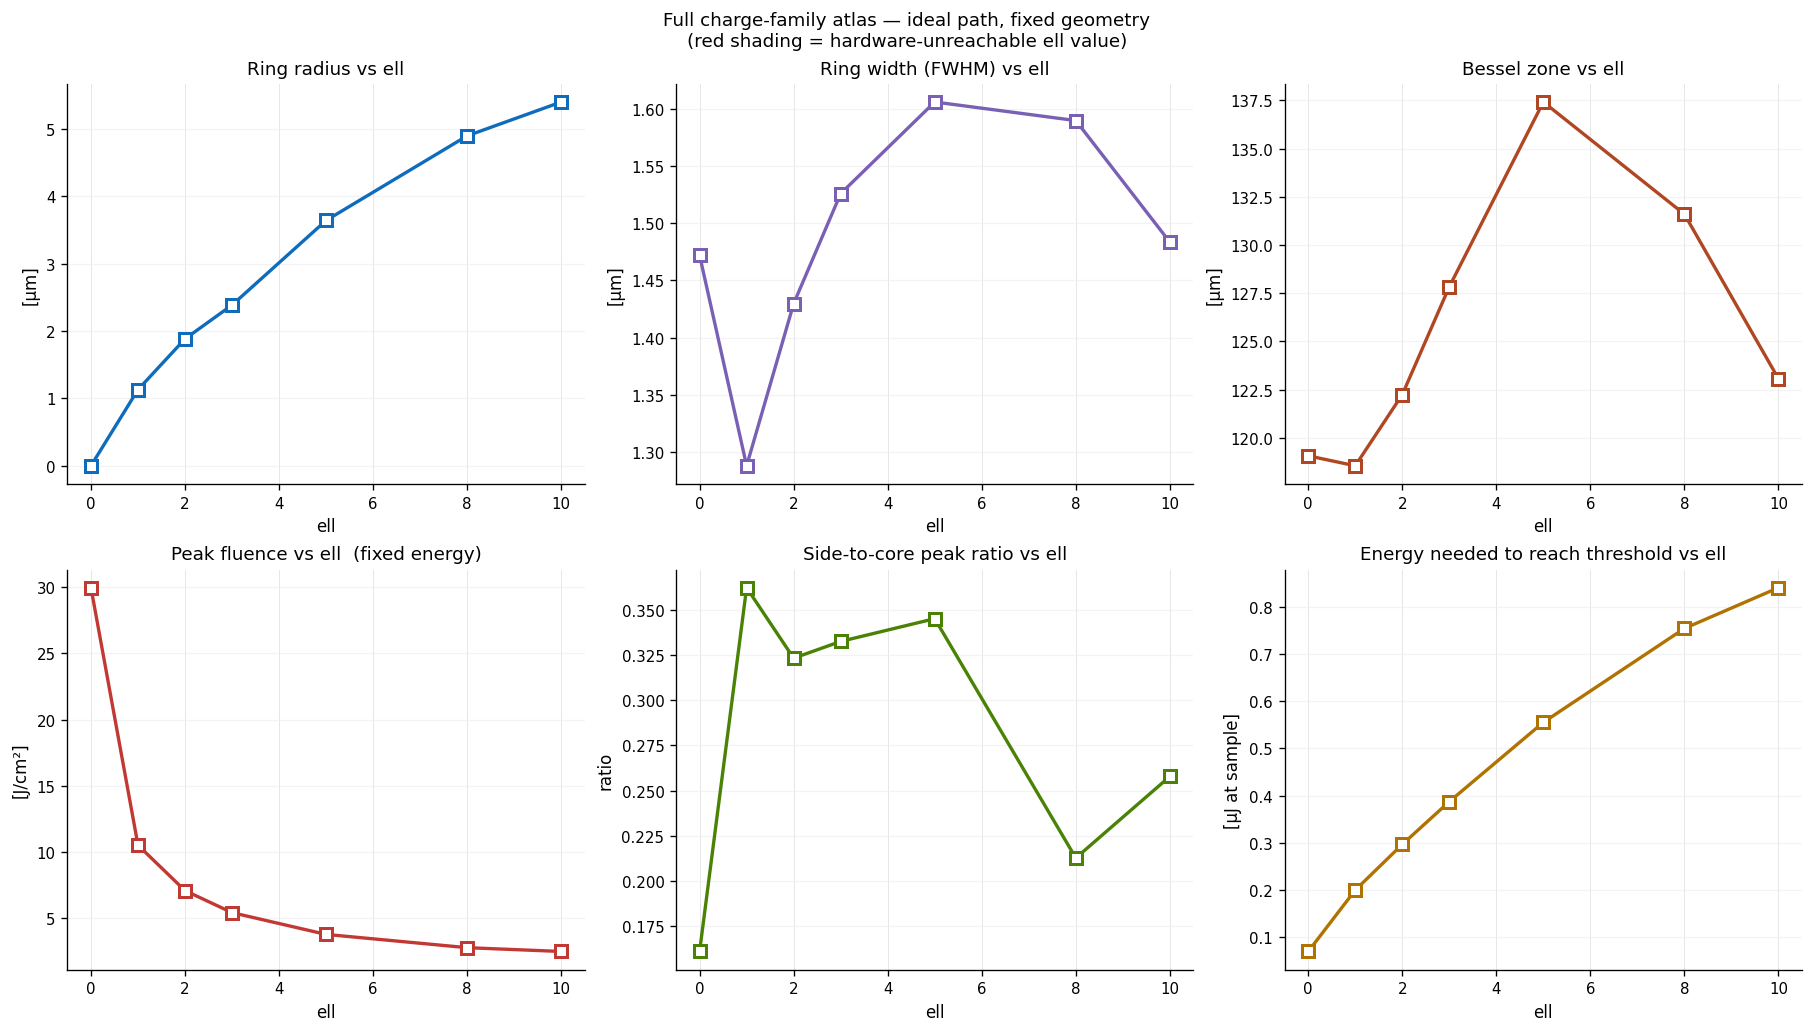

C:\PhD\Code\Publication_Study\outputs\figures\publication_study\ell_family_atlas.png


In [11]:
import numpy as np

print("Running full ell-family comparison (ell = 0, 1, 2, 3, 5, 8, 10) ...")
ell_family_df = bt.run_ell_family_comparison(base, preset=PRESET, save=False)
ell_family_df.to_csv(PUB_EXP_CSV / "scalar_ell_family_comparison.csv", index=False)
display(ell_family_df[[
    "ell", "ring_radius_um", "ring_width_um", "bessel_zone_um",
    "peak_fluence_J_cm2", "side_to_core_peak_ratio",
    "energy_at_sample_for_threshold_uJ", "hardware_reachable", "qa_status",
]])

ells_f = ell_family_df["ell"].tolist()
mk_sq = dict(marker="s", linewidth=2.0, markersize=7, markerfacecolor="white", markeredgewidth=1.8)

fig, ax = plt.subplots(2, 3, figsize=(15, 8.5), constrained_layout=True)

ax[0, 0].plot(ells_f, ell_family_df["ring_radius_um"], color="#0f6cbd", **mk_sq)
ax[0, 0].set_title("Ring radius vs ell")
ax[0, 0].set_xlabel("ell"); ax[0, 0].set_ylabel("[\u03bcm]")

ax[0, 1].plot(ells_f, ell_family_df["ring_width_um"], color="#7960b5", **mk_sq)
ax[0, 1].set_title("Ring width (FWHM) vs ell")
ax[0, 1].set_xlabel("ell"); ax[0, 1].set_ylabel("[\u03bcm]")

ax[0, 2].plot(ells_f, ell_family_df["bessel_zone_um"], color="#b14623", **mk_sq)
ax[0, 2].set_title("Bessel zone vs ell")
ax[0, 2].set_xlabel("ell"); ax[0, 2].set_ylabel("[\u03bcm]")

ax[1, 0].plot(ells_f, ell_family_df["peak_fluence_J_cm2"], color="#c23934", **mk_sq)
ax[1, 0].set_title("Peak fluence vs ell  (fixed energy)")
ax[1, 0].set_xlabel("ell"); ax[1, 0].set_ylabel("[J/cm\u00b2]")

ax[1, 1].plot(ells_f, ell_family_df["side_to_core_peak_ratio"], color="#498205", **mk_sq)
ax[1, 1].set_title("Side-to-core peak ratio vs ell")
ax[1, 1].set_xlabel("ell"); ax[1, 1].set_ylabel("ratio")

ax[1, 2].plot(ells_f, ell_family_df["energy_at_sample_for_threshold_uJ"], color="#b07200", **mk_sq)
ax[1, 2].set_title("Energy needed to reach threshold vs ell")
ax[1, 2].set_xlabel("ell"); ax[1, 2].set_ylabel("[\u03bcJ at sample]")

# Shade hardware-unreachable points
if "hardware_reachable" in ell_family_df.columns:
    for _, row in ell_family_df.iterrows():
        if not row["hardware_reachable"]:
            for a in ax.ravel():
                a.axvspan(row["ell"] - 0.35, row["ell"] + 0.35, alpha=0.08, color="red")

for a in ax.ravel():
    a.spines[["top", "right"]].set_visible(False)
    a.grid(axis="y", color="#eeeeee", lw=0.8)

fig.suptitle(
    "Full charge-family atlas — ideal path, fixed geometry\n"
    "(red shading = hardware-unreachable ell value)",
    fontsize=11,
)
ell_family_path = PUB_OUT["figures"] / "ell_family_atlas.png"
fig.savefig(ell_family_path, dpi=220, bbox_inches="tight")
plt.show()
print(ell_family_path)

## Parameter Sensitivity Tornado

A one-at-a-time (OAT) sensitivity study sweeps every lab-controllable knob around the baseline and ranks them by their normalised effect on Bessel zone length. The tornado chart immediately shows which levers matter most for experiment planning and which are essentially inert. Knobs pointing right (positive) grow the zone; knobs pointing left (negative) compress it.

Running one-at-a-time sensitivity study (~35 cases) ...


,knob,sens
11,target_bessel_length_um,8.973063e-01
10,target_core_diameter_um,-6.581876e-01
9,write_depth_um,-2.114055e-01
8,ell,-1.703386e-01
7,fill_factor,-1.936690e-15
6,slm_phase_bits,4.575006e-16
5,blaze_period_px,-4.417003e-16
4,beam_radius_on_slm_mm,-3.076279e-16
3,rep_rate_kHz,2.841886e-16
2,scan_speed_mm_s,1.751005e-16


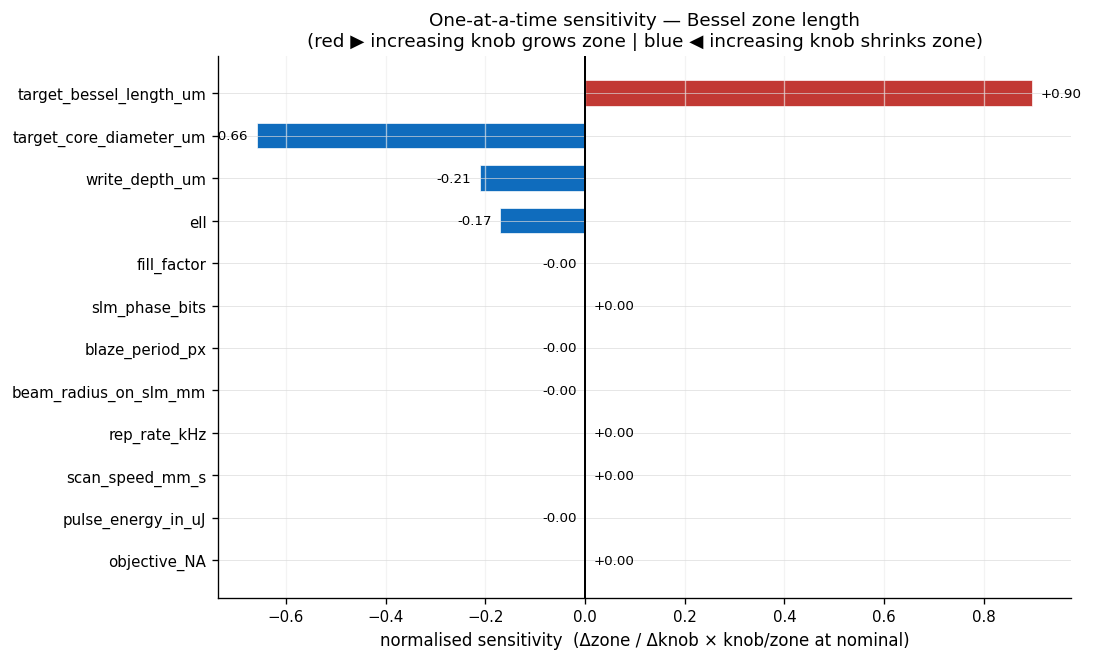

C:\PhD\Code\Publication_Study\outputs\figures\publication_study\sensitivity_tornado.png


: 

In [ ]:
import numpy as np

print("Running one-at-a-time sensitivity study (~35 cases) ...")
oat_df = bt.run_oat_sensitivity(base, preset=PRESET, save=False)
oat_df.to_csv(PUB_EXP_CSV / "scalar_oat_sensitivity_raw.csv", index=False)

# Deduplicate to one sensitivity value per knob
sens_rows = (
    oat_df.dropna(subset=["normalised_zone_sensitivity"])
    .drop_duplicates("knob")[["knob", "normalised_zone_sensitivity"]]
    .rename(columns={"normalised_zone_sensitivity": "sens"})
    .sort_values("sens", key=abs, ascending=True)  # ascending so largest bar is at top
    .reset_index(drop=True)
)
sens_rows.to_csv(PUB_EXP_CSV / "scalar_oat_sensitivity_ranked.csv", index=False)
display(sens_rows.sort_values("sens", key=abs, ascending=False))

# --- Tornado chart ---
fig_h = max(4.5, len(sens_rows) * 0.45)
fig, ax = plt.subplots(figsize=(9, fig_h), constrained_layout=True)
colors_t = ["#c23934" if s >= 0 else "#0f6cbd" for s in sens_rows["sens"]]
bars = ax.barh(sens_rows["knob"], sens_rows["sens"], color=colors_t, height=0.6, edgecolor="white", linewidth=0.4)
ax.axvline(0, color="black", lw=1.2)
# Label each bar with its value
for bar, s in zip(bars, sens_rows["sens"]):
    ha = "left" if s >= 0 else "right"
    offset = 0.01 * (ax.get_xlim()[1] - ax.get_xlim()[0] + 1e-6)
    ax.text(s + (offset if s >= 0 else -offset),
            bar.get_y() + bar.get_height() / 2,
            f"{s:+.2f}", va="center", ha=ha, fontsize=8)
ax.set_xlabel("normalised sensitivity  (\u0394zone / \u0394knob \u00d7 knob/zone at nominal)")
ax.set_title("One-at-a-time sensitivity — Bessel zone length\n"
             "(red \u25b6 increasing knob grows zone | blue \u25c0 increasing knob shrinks zone)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", color="#eeeeee", lw=0.8)

tornado_path = PUB_OUT["figures"] / "sensitivity_tornado.png"
fig.savefig(tornado_path, dpi=220, bbox_inches="tight")
plt.show()
print(tornado_path)